# Explanatory Analysis of Sales, Profitability and Operational Performance in an Indian Retail Business

**Module:** M504 AI and Applications  
**Assessment:** Individual Project  

This project presents an explanatory data analysis of retail transaction data from an Indian retail business. The analysis focuses on sales performance, profitability, product performance, customer segments, regional differences, discounting and logistics.

## 1. Business Context

### 1.1 Client Company

For this project, the client is considered to be an Indian retail business that sells food-related products to different customer segments, including hotels and hospitals, restaurant chains, stand-alone restaurants and personal users.

The company records transaction-level information covering product characteristics, customer segments, geographical locations, pricing, discounts, freight arrangements, sales, quantity ordered and profit. The company therefore has a substantial amount of operational and financial information that can be analysed to support business decision-making.

The role of the data science consultant is to examine these data systematically and identify patterns that may be useful for improving commercial and operational performance.

### 1.2 Business Problem

The retail company needs a clearer understanding of the factors associated with its sales performance, profitability and operational efficiency. Although the company records sales and profit for individual transactions, these figures alone do not explain which products, regions, customer segments, discounts or freight arrangements are associated with stronger or weaker outcomes.

A particular area of interest is the presence of loss-making transactions. The business therefore needs to understand where these losses occur and whether they are associated with factors such as discount levels, product categories, customer segments, geographical regions or logistics.

The central business problem addressed in this project is:

> **How can transaction-level retail data be used to explain differences in sales, profitability and operational performance and identify areas where the business may improve its decision-making?**

The analysis is explanatory rather than predictive. It aims to identify patterns and relationships in the historical data and translate these findings into evidence-based business recommendations.

### 1.3 Dataset

The analysis uses the `INDIA RETAIL DATA` dataset. The dataset contains 2,534 transaction records and 18 variables covering financial, product, customer-segment, geographical and operational information.

The variables include order priority, discount offered, unit price, freight expenses, freight mode, segment, product type, product sub-category, product container, state, city, region, country, order date, ship date, profit, quantity ordered and sales.

The dataset covers transactions between January 2010 and December 2013. This provides sufficient temporal information to examine changes in sales and profitability over time.

The dataset source URL will be provided in the final notebook as required by the assessment brief.


Link - https://www.kaggle.com/datasets/winstonbobby/indian-retail-sales


### 1.4 Analytical Objectives

The analysis has the following objectives:

1. Examine the structure and quality of the retail transaction dataset.
2. Identify sales and profitability trends over time.
3. Compare the performance of different product types and product sub-categories.
4. Examine differences in sales and profitability across geographical regions.
5. Compare purchasing and profitability patterns across customer segments.
6. Investigate the relationship between discounts and profitability.
7. Examine the relationship between freight mode, delivery time, freight expenses and profitability.
8. Identify characteristics associated with loss-making transactions.
9. Examine whether order priority is associated with differences in delivery and financial performance.
10. Translate the analytical findings into practical business implications and data-driven recommendations.

## 2. Data Exploration

Before conducting the main explanatory analysis, the dataset is explored to understand its structure, variable types, completeness and potential data-quality issues. This stage is important because decisions made during preprocessing should be based on the characteristics of the data rather than assumptions.

The exploration examines the dimensions of the dataset, data types, missing observations, duplicate records, numerical distributions and categorical variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "INDIA_RETAIL_DATA.xlsx"

df = pd.read_excel(file_path)

df.head()

,Order Priority,Discount offered,Unit Price,Freight Expenses,Freight Mode,Segment,Product Type,Product Sub-Category,Product Container,State,City,Region,Country,Order Date,Ship Date,Profit,QtyOrdered,Sales
0,High,0.06,40.98,2.99,Regular Air,Personel Usage,Processed Meat,Bacon,Small Box,Madhya Pradesh,Rewa,West,India,2010-01-02,2010-01-04,-19.0992,3,124.81
1,High,0.05,155.06,7.07,Regular Air,Hotels / Hospitals,Processed Meat,Fresh Water Eel,Small Box,Meghalaya,Shillong,East,India,2010-01-02,2010-01-09,845.6640,8,1225.60
2,High,0.09,9.11,2.15,Express Air,Personel Usage,Processed Meat,Smoked Salmon,Wrap Bag,Maharashtra,Parbhani,West,India,2010-01-02,2010-01-04,20.2996,4,34.41
3,High,0.08,15.04,1.97,Regular Air,Personel Usage,Processed Meat,Smoked Salmon,Wrap Bag,Maharashtra,Parbhani,West,India,2010-01-02,2010-01-02,108.5163,11,157.27
4,High,0.03,4.26,1.20,Regular Air,Restaurant Chain,Processed Meat,Foie Gras,Wrap Bag,Uttar Pradesh,Ghaziabad,North,India,2010-01-03,2010-01-04,9.8200,29,122.23


The dataset is loaded into a Pandas DataFrame using `read_excel()`. The first five observations are displayed to verify that the file has been imported correctly and to provide an initial view of the variables and their values.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 2534
Number of columns: 18

Column names:
['Order Priority', 'Discount offered', 'Unit Price', 'Freight Expenses', 'Freight Mode', 'Segment', 'Product Type', 'Product Sub-Category', 'Product Container', 'State', 'City', 'Region', 'Country', 'Order Date', 'Ship Date', 'Profit', 'QtyOrdered', 'Sales']


The dataset contains 2,534 transaction records and 18 variables. The variables represent different aspects of the retail operation, including financial measures such as sales and profit, product information, customer segments, geographical information and logistics.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534 entries, 0 to 2533
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order Priority        2534 non-null   object        
 1   Discount offered      2534 non-null   float64       
 2   Unit Price            2534 non-null   float64       
 3   Freight Expenses      2534 non-null   float64       
 4   Freight Mode          2534 non-null   object        
 5   Segment               2534 non-null   object        
 6   Product Type          2534 non-null   object        
 7   Product Sub-Category  2534 non-null   object        
 8   Product Container     2534 non-null   object        
 9   State                 2534 non-null   object        
 10  City                  2534 non-null   object        
 11  Region                2534 non-null   object        
 12  Country               2534 non-null   object        
 13  Order Date        

The `info()` output is used to examine the data types and completeness of the variables. The dataset contains numerical variables such as discount, unit price, freight expenses, profit, quantity ordered and sales. Several variables are categorical, including segment, product type, region and freight mode. The order and shipping dates are stored as datetime variables.

## Missing Values

In [5]:
missing_values = df.isnull().sum()

missing_values

Order Priority          0
Discount offered        0
Unit Price              0
Freight Expenses        0
Freight Mode            0
Segment                 0
Product Type            0
Product Sub-Category    0
Product Container       0
State                   0
City                    0
Region                  0
Country                 0
Order Date              0
Ship Date               0
Profit                  0
QtyOrdered              0
Sales                   0
dtype: int64

In [6]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


The missing-value check shows that there are no missing observations across the 18 variables. Therefore, there is no requirement to impute or remove observations because of missing data.

## Duplicate Records

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


The dataset contains no exact duplicate rows. Therefore, no records are removed at this stage. 

### Numerical Statistics

In [8]:
numerical_columns = [
    "Discount offered",
    "Unit Price",
    "Freight Expenses",
    "Profit",
    "QtyOrdered",
    "Sales"
]

df[numerical_columns].describe().round(2)

,Discount offered,Unit Price,Freight Expenses,Profit,QtyOrdered,Sales
count,2534.00,2534.00,2534.00,2534.00,2534.00,2534.00
mean,0.05,100.15,12.22,112.58,14.24,992.62
std,0.03,357.02,16.09,1055.21,16.01,3147.34
min,0.00,0.99,0.49,-14369.12,1.00,1.62
25%,0.02,6.48,2.99,-86.38,5.00,62.59
50%,0.05,20.89,6.05,1.23,10.00,191.16
75%,0.08,89.95,12.98,121.26,17.00,793.85
max,0.10,6783.02,110.20,16332.41,170.00,100119.16


Descriptive statistics are calculated for the main numerical variables. The results provide information about the central tendency and spread of the financial, pricing, quantity and discount variables.

The sales variable has a mean of approximately 992.62, while the mean profit is approximately 112.58. The quantity ordered has a mean of approximately 14.24 units per transaction.

The large difference between the minimum and maximum values for some variables indicates that transactions vary considerably in scale. For example, sales range from approximately 1.62 to 100,119.16, while unit price ranges from approximately 0.99 to 6,783.02. These differences should be considered when interpreting aggregate results and may justify further investigation of extreme observations.

### Additional Profit Analysis

In [10]:
print("Loss-making transactions:", (df["Profit"] < 0).sum())
print("Profit-making transactions:", (df["Profit"] > 0).sum())
print("Zero-profit transactions:", (df["Profit"] == 0).sum())

Loss-making transactions: 1248
Profit-making transactions: 1286
Zero-profit transactions: 0


Profit provides an important indicator of financial performance. The dataset contains both profitable and loss-making transactions. In particular, 1,248 transactions have negative profit, while 1,286 transactions have positive profit.

### Categorical Variables

In [12]:
categorical_columns = [
    "Order Priority",
    "Freight Mode",
    "Segment",
    "Product Type",
    "Product Sub-Category",
    "Product Container",
    "State",
    "City",
    "Region",
    "Country"
]

categorical_summary = pd.DataFrame({
    "Variable": categorical_columns,
    "Unique Values": [df[col].nunique() for col in categorical_columns]
})

categorical_summary

,Variable,Unique Values
0,Order Priority,5
1,Freight Mode,3
2,Segment,4
3,Product Type,3
4,Product Sub-Category,17
5,Product Container,7
6,State,22
7,City,339
8,Region,4
9,Country,1


The categorical variables provide several dimensions for comparing business performance. The dataset contains 4 regions, 22 states and 339 cities, allowing geographical performance to be examined at different levels.

There are also 4 customer segments, 3 product types, 17 product sub-categories, 7 product-container categories and 3 freight modes. Order priority contains 5 categories.

The country variable contains only one unique value, India. Therefore, country-level comparisons would not provide meaningful variation and the geographical analysis will instead focus on regions, states and cities.

### Useful category distributions

In [14]:
for column in ["Order Priority", "Freight Mode", "Segment", 
               "Product Type", "Region"]:
    print(f"\n{column}")
    print(df[column].value_counts())


Order Priority
Order Priority
High             1624
Low               259
Not Specified     238
Medium            212
Critical          201
Name: count, dtype: int64

Freight Mode
Freight Mode
Regular Air       1892
Delivery Truck     342
Express Air        300
Name: count, dtype: int64

Segment
Segment
Hotels / Hospitals         869
Restaurant Chain           625
Personel Usage             591
Stand Alone Restaurants    449
Name: count, dtype: int64

Product Type
Product Type
Processed Meat    1407
Canned Foods       631
Preserved Food     496
Name: count, dtype: int64

Region
Region
North    890
West     811
South    542
East     291
Name: count, dtype: int64


Frequency counts are used to examine how observations are distributed across the main categorical variables. This helps identify dominant categories and provides context for later comparisons.

For example, the freight mode distribution shows the extent to which the company relies on Regular Air, Express Air and Delivery Truck. Similarly, examining the segment and regional distributions helps determine whether later comparisons are based on sufficiently represented groups.

### Data Quality Discussion

### 2.7 Data Quality Discussion

The initial exploration indicates that the dataset is complete, with no missing values or exact duplicate records. The order and shipping dates are also available as datetime variables, which supports temporal and delivery-time analysis.

However, data quality is not limited to missing values and duplicates. The numerical statistics indicate considerable variation in variables such as unit price, sales and profit. In particular, sales and profit contain relatively large maximum values compared with their median values, suggesting that some transactions may have substantially different scales from typical observations. These observations should not automatically be removed because they may represent genuine high-value transactions.

The dataset also contains a single country value, India. Consequently, country is not useful for comparative analysis and geographical comparisons will focus on region, state and city.

There are also categorical values such as 'Not Specified' within order priority. These values will be retained because they represent an existing category in the source data rather than a missing numerical observation.

Overall, the exploration suggests that the dataset does not require extensive corrective cleaning. The main preprocessing requirement is therefore to create analytical variables that support the business questions while preserving the original transaction records.

# DATA PREPROCESSING

## 3. Data Preprocessing

The preprocessing stage prepares the dataset for explanatory analysis. Because the initial exploration identified no missing values or exact duplicate records, the original observations are retained.

The main preprocessing activities involve validating the date variables and creating derived variables that provide additional business meaning. These include delivery duration, profit margin, calendar-based variables and a profitability classification.

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


### Delivery Days

In [18]:
df["Delivery Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Delivery Days"].describe().round(2)

count    2534.00
mean        2.03
std         2.66
min         0.00
25%         1.00
50%         2.00
75%         2.00
max        92.00
Name: Delivery Days, dtype: float64

In [20]:
print("Negative delivery times:", (df["Delivery Days"] < 0).sum())
print("Maximum delivery time:", df["Delivery Days"].max(), "days")

Negative delivery times: 0
Maximum delivery time: 92 days


A new `Delivery Days` variable is created by calculating the difference between the shipping date and order date. This variable represents the elapsed time between placing an order and shipping it.

The validation check identifies no negative delivery durations, indicating that the shipping date does not occur before the corresponding order date in the dataset. Delivery duration ranges from 0 to 92 days.

This derived variable will support the later investigation of freight modes and order priorities in relation to operational performance.

### Profit Margin

In [21]:
df["Profit Margin (%)"] = np.where(
    df["Sales"] != 0,
    (df["Profit"] / df["Sales"]) * 100,
    np.nan
)

df["Profit Margin (%)"].describe().round(2)

count     2534.00
mean        63.28
std       2708.66
min     -17672.03
25%        -55.82
50%          0.56
75%         45.31
max      99998.30
Name: Profit Margin (%), dtype: float64

In [23]:
print("Missing profit margins:", df["Profit Margin (%)"].isnull().sum())

Missing profit margins: 0


Profit margin is calculated as profit relative to sales. This provides a proportional measure of profitability and is useful when comparing transactions or groups with different sales volumes.

The calculation divides profit by sales and multiplies the result by 100. The calculation is only performed where sales are non-zero to avoid division by zero.

Profit margin will be used alongside total profit and sales rather than replacing them. This distinction is important because a group can generate a high total profit while having a different margin profile from another group.

### Time Variables

In [24]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()

df[[
    "Order Date",
    "Order Year",
    "Order Month",
    "Order Month Name"
]].head()

,Order Date,Order Year,Order Month,Order Month Name
0,2010-01-02,2010,1,January
1,2010-01-02,2010,1,January
2,2010-01-02,2010,1,January
3,2010-01-02,2010,1,January
4,2010-01-03,2010,1,January


Calendar variables are derived from the order date to support time-based analysis. The year and month variables allow sales and profitability to be aggregated across different periods.

The month name is also created to make the results easier to interpret in visualisations. These variables will be used when investigating changes in sales and profitability over time.

### Profitability Classification

In [26]:
df["Profitability"] = np.where(
    df["Profit"] < 0,
    "Loss-making",
    "Profit-making"
)

df["Profitability"].value_counts()

Profitability
Profit-making    1286
Loss-making      1248
Name: count, dtype: int64

A categorical profitability variable is created to distinguish loss-making transactions from profit-making transactions. Transactions with negative profit are classified as 'Loss-making', while transactions with positive profit are classified as 'Profit-making'.

There are no zero-profit transactions in the dataset, so the two categories provide a complete classification of the observations.

### Final Preprocessing Check

In [27]:
print("Dataset shape after preprocessing:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNew variables:")
print([
    "Delivery Days",
    "Profit Margin (%)",
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Profitability"
])

Dataset shape after preprocessing: (2534, 24)

Missing values:
0

Duplicate rows:
0

New variables:
['Delivery Days', 'Profit Margin (%)', 'Order Year', 'Order Month', 'Order Month Name', 'Profitability']


# 4. Explanatory Data Analysis

## 4.1 Business Question 1: How have sales and profitability changed over time?

### Why is this important?

Understanding how sales and profitability change over time allows management to identify periods of strong and weak business performance. Examining sales alone may not provide a complete picture because an increase in sales does not necessarily result in an increase in profit.

In [28]:
yearly_performance = (
    df.groupby("Order Year")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("QtyOrdered", "sum"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
)

yearly_performance

,Order Year,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
0,2010,564138.89,79086.078608,7355,544
1,2011,511947.18,79117.087068,7699,518
2,2012,648252.47,78369.974208,9309,612
3,2013,790969.96,48694.945239,11717,860


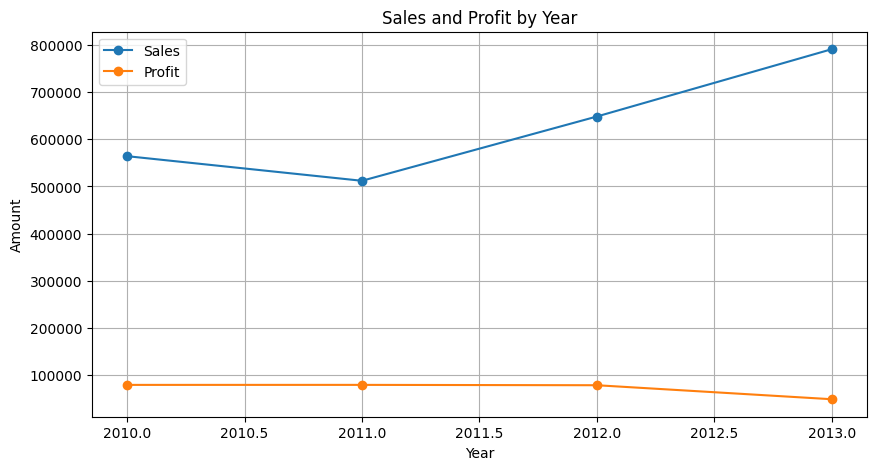

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_performance["Order Year"],
    yearly_performance["Total_Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_performance["Order Year"],
    yearly_performance["Total_Profit"],
    marker="o",
    label="Profit"
)

plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

Sales increased overall from 564,138.89 in 2010 to 790,969.96 in 2013, despite a decline in 2011. Total quantity and number of orders also increased over the period. However, total profit fell from 79,086.08 in 2010 to 48,694.95 in 2013. This indicates that higher sales and order volumes did not translate into higher profitability, highlighting a need to examine factors affecting profit margins.

## 4.2 Business Question 2: Which product types and product sub-categories generate the highest sales and profit?

### Why is this important?

Understanding product-level performance can help management identify the products that contribute most to revenue and profitability. A product with high sales may not necessarily generate high profit, so both measures should be considered.

This analysis examines sales, profit and quantity ordered across product types and product sub-categories.

In [31]:
product_performance = (
    df.groupby(["Product Type", "Product Sub-Category"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("QtyOrdered", "sum"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

product_performance.head(10)

,Product Type,Product Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
2,Canned Foods,Sliced Pineapple,461919.56,6598.573340,1349,121
1,Canned Foods,Quail Eggs,305430.26,70894.158888,4070,281
7,Preserved Food,Sundried Tomatoes,296935.99,28466.776600,1657,101
4,Preserved Food,Jams,274325.88,-2242.642046,1616,114
3,Canned Foods,Wild Berry,190132.48,13530.290240,283,24
6,Preserved Food,Pickle,189365.13,11552.214400,800,50
11,Processed Meat,Fresh Water Eel,168274.72,13693.999368,2141,158
5,Preserved Food,Marmalade,136595.76,27410.742757,3128,231
8,Processed Meat,Bacon,112856.30,24145.380523,3374,271
0,Canned Foods,Assorted Fruits,106315.50,11798.202480,2866,205


In [32]:
top_subcategories = (
    df.groupby("Product Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

top_subcategories.head(10)

,Total_Sales,Total_Profit
Product Sub-Category,,
Sliced Pineapple,461919.56,6598.573340
Quail Eggs,305430.26,70894.158888
Sundried Tomatoes,296935.99,28466.776600
Jams,274325.88,-2242.642046
Wild Berry,190132.48,13530.290240
Pickle,189365.13,11552.214400
Fresh Water Eel,168274.72,13693.999368
Marmalade,136595.76,27410.742757
Bacon,112856.30,24145.380523


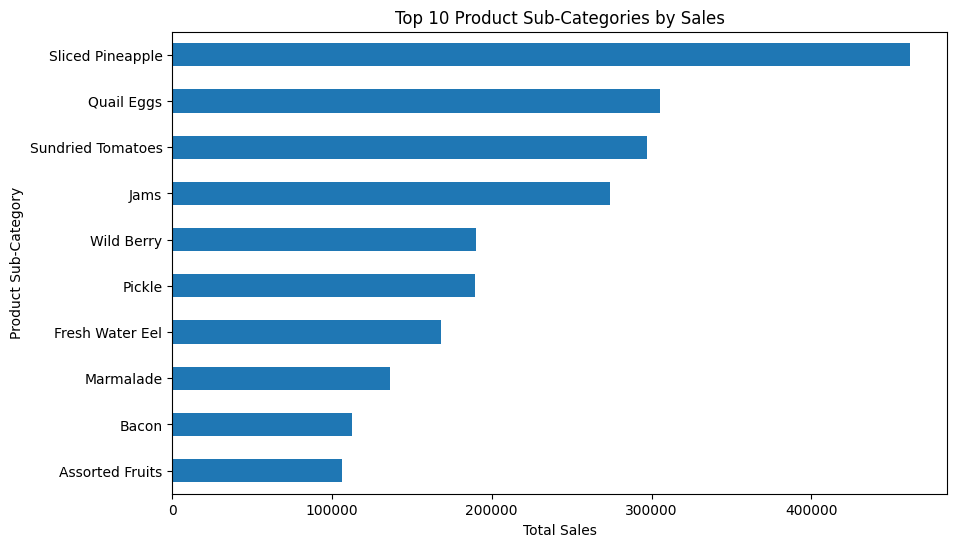

In [34]:
top_subcategories.head(10)["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Product Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Sub-Category")
plt.show()

### Interpretation

The analysis shows clear differences in sales and profitability across product sub-categories. Sliced Pineapple recorded the highest sales at 461,919.56, while Quail Eggs generated the highest profit at 70,894.16. Jams was the only product among the top 10 with a negative profit of -2,242.64. These results indicate that high sales do not always correspond to high profitability across product sub-categories.

## 4.3 Business Question 3: How does sales and profitability performance differ across India's regions?

### Why is this important?

The company operates across different geographical regions. Comparing regional performance can help management understand where sales and profit are concentrated and whether some regions have substantially different financial outcomes.

The analysis compares total sales, profit, quantity ordered and transaction volume across regions.

In [35]:
regional_performance = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("QtyOrdered", "sum"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

regional_performance

,Region,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
1,North,956630.55,118198.711616,13579,890
3,West,941962.19,79684.151639,14236,811
2,South,388339.53,55817.792036,5485,542
0,East,228376.23,31567.429831,2780,291


### Sales and Profit

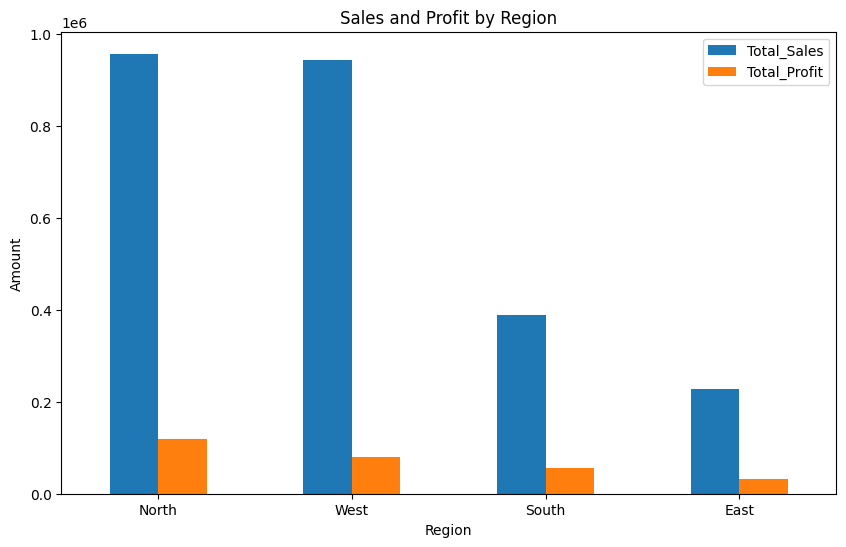

In [36]:
regional_performance.set_index("Region")[
    ["Total_Sales", "Total_Profit"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.show()

### State-Level Analysis

In [37]:
state_performance = (
    df.groupby(["Region", "State"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

state_performance.head(15)

,Region,State,Total_Sales,Total_Profit,Number_of_Orders
10,North,Uttar Pradesh,641059.04,104213.124465,473
18,West,Madhya Pradesh,631159.60,26904.481357,359
4,North,Bihar,160228.30,23672.749109,194
15,South,Tamil Nadu,138432.35,3869.001868,184
19,West,Maharashtra,136383.49,32250.748800,172
3,East,West Bengal,136218.27,25402.282748,150
12,South,Andhra Pradesh,93493.60,9931.500387,124
17,West,Gujarat,71625.96,12889.125504,112
21,West,Rajasthan,67030.83,181.814642,111
9,North,Jharkhand,62561.30,3099.905808,70


### Interpretation

The North region recorded the highest sales (956,630.55) and profit (118,198.71), followed closely by the West region. The South and East regions had considerably lower sales and profit. At the state level, Uttar Pradesh generated the highest sales and profit, while Haryana recorded a negative profit. These differences show that regional and state-level performance varies substantially across the business.

## 4.4 Business Question 4: How does purchasing and profitability performance differ between customer segments?

### Why is this important?

Different customer segments may have different purchasing patterns, sales volumes and profitability. Understanding these differences can help the company evaluate which types of customers contribute to its financial performance.

The analysis compares sales, profit, quantity ordered and transaction volume across the customer segments in the dataset.

In [39]:
segment_performance = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("QtyOrdered", "sum"),
          Number_of_Orders=("Sales", "count"),
          Average_Sales=("Sales", "mean"),
          Average_Profit=("Profit", "mean")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

segment_performance

,Segment,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Average_Sales,Average_Profit
0,Hotels / Hospitals,841291.78,78918.374864,11448,869,968.114822,90.815161
1,Personel Usage,667768.32,43027.339246,9418,591,1129.895635,72.804297
2,Restaurant Chain,592401.83,79915.194660,9682,625,947.842928,127.864311
3,Stand Alone Restaurants,413846.57,83407.176352,5532,449,921.707283,185.762085


### Profit Margin by Segment

In [40]:
segment_performance["Profit_Margin (%)"] = (
    segment_performance["Total_Profit"] /
    segment_performance["Total_Sales"] * 100
)

segment_performance.sort_values(
    "Profit_Margin (%)",
    ascending=False
)

,Segment,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Average_Sales,Average_Profit,Profit_Margin (%)
3,Stand Alone Restaurants,413846.57,83407.176352,5532,449,921.707283,185.762085,20.154130
2,Restaurant Chain,592401.83,79915.194660,9682,625,947.842928,127.864311,13.490032
0,Hotels / Hospitals,841291.78,78918.374864,11448,869,968.114822,90.815161,9.380619
1,Personel Usage,667768.32,43027.339246,9418,591,1129.895635,72.804297,6.443453


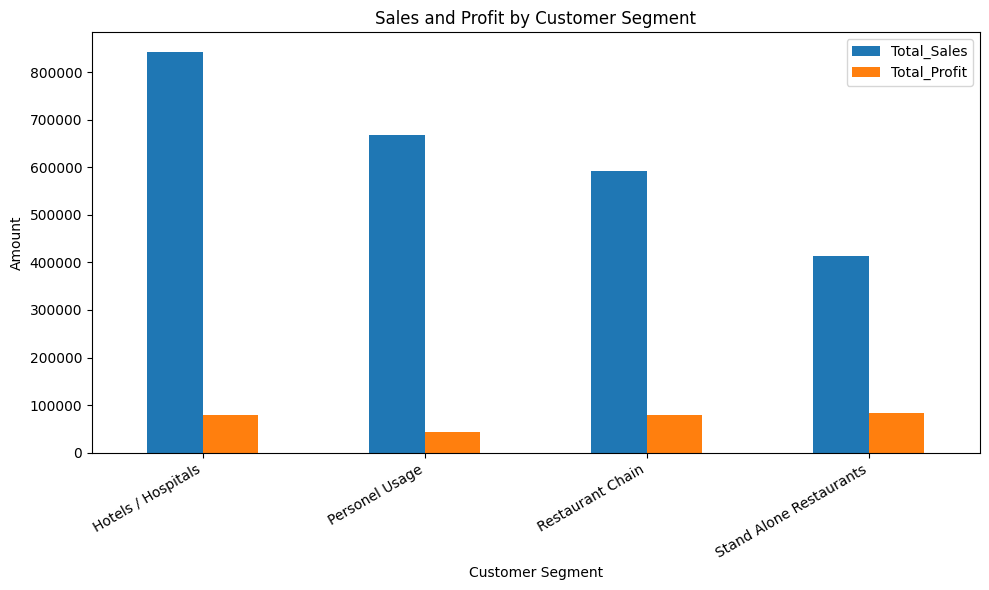

In [41]:
segment_performance.set_index("Segment")[
    ["Total_Sales", "Total_Profit"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The Hotels/Hospitals segment generated the highest total sales at 841,291.78, while Stand Alone Restaurants recorded the highest total profit at 83,407.18 and the highest profit margin of 20.15%. Personel Usage had the lowest profit margin at 6.44% despite relatively high sales. This shows that sales volume and profitability differ across customer segments.

# Business Question 5 — Discount and Profitability

## 4.5 Business Question 5: What is the relationship between discounts and sales profitability?

### Why is this important?

Discounts can influence purchasing behaviour and sales value, but they can also reduce the amount of profit generated from a transaction. Understanding the relationship between discount levels and profitability can therefore help management evaluate the financial implications of discounting.

This analysis examines whether different discount levels are associated with differences in sales, profit and profit margin.

In [43]:
discount_correlation = df[
    ["Discount offered", "Sales", "Profit", "Profit Margin (%)"]
].corr()

discount_correlation

,Discount offered,Sales,Profit,Profit Margin (%)
Discount offered,1.000000,-0.027153,-0.031247,-0.000672
Sales,-0.027153,1.000000,0.270358,-0.006050
Profit,-0.031247,0.270358,1.000000,0.237499
Profit Margin (%),-0.000672,-0.006050,0.237499,1.000000


### Discount Groups

In [57]:
# Convert discount to percentage
df["Discount (%)"] = df["Discount offered"] * 100

df["Discount Band"] = pd.cut(
    df["Discount (%)"],
    bins=[-0.001, 5, 10, 15, 20, 100],
    labels=[
        "0-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20%+"
    ]
)

discount_analysis = (
    df.groupby("Discount Band", observed=False)
      .agg(
          Average_Sales=("Sales", "mean"),
          Average_Profit=("Profit", "mean"),
          Number_of_Transactions=("Sales", "count")
      )
      .reset_index()
)

discount_analysis

,Discount Band,Average_Sales,Average_Profit,Number_of_Transactions
0,0-5%,1063.197459,150.552292,1393
1,5-10%,906.463138,66.212745,1141
2,10-15%,NaN,NaN,0
3,15-20%,NaN,NaN,0
4,20%+,NaN,NaN,0


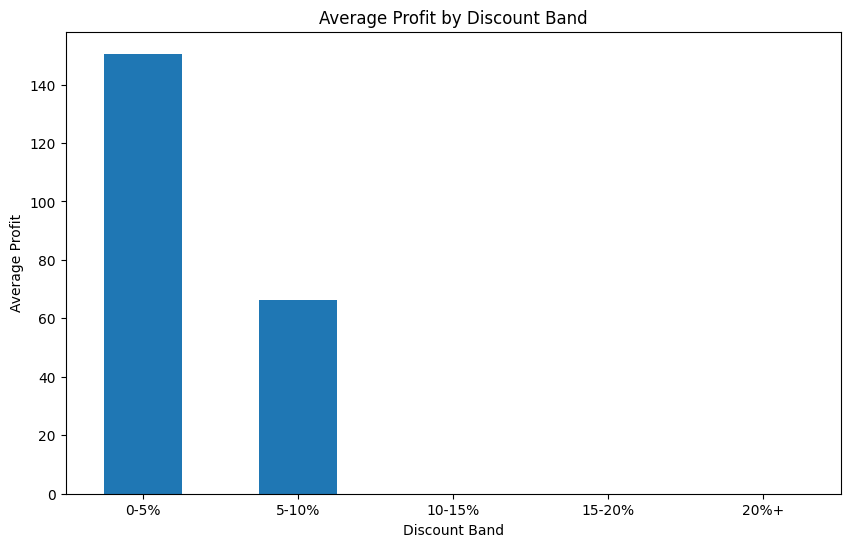

In [58]:
discount_analysis.plot(
    x="Discount Band",
    y="Average_Profit",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.show()

### Interpretation

The analysis shows that discounts in the dataset range from below 5% to 10%. Transactions with discounts of 0–5% have a higher average sales value (1063.20) and average profit (150.55) than transactions with discounts of 5–10%, which have average sales of 906.46 and average profit of 66.21. The correlation analysis also shows very weak relationships between discount and sales and between discount and profit. This suggests that discount level alone does not explain the differences in profitability. The dataset contains no discounts above 10%, so the effect of higher discount levels cannot be assessed.

# Business Question 6 — Freight and Delivery Performance

## 4.6 Business Question 6: How does freight mode affect delivery time, freight expenses and profitability?

### Why is this important?

Logistics can affect both operational efficiency and financial performance. Different freight modes may involve different delivery durations and transportation expenses.

The dataset contains order date, ship date, freight mode, freight expenses, sales and profit. These variables allow delivery performance and financial outcomes to be examined together.

In [47]:
freight_performance = (
    df.groupby("Freight Mode")
      .agg(
          Average_Delivery_Days=("Delivery Days", "mean"),
          Average_Freight_Expense=("Freight Expenses", "mean"),
          Total_Freight_Expense=("Freight Expenses", "sum"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
)

freight_performance.round(2)

,Freight Mode,Average_Delivery_Days,Average_Freight_Expense,Total_Freight_Expense,Total_Sales,Total_Profit,Number_of_Orders
0,Delivery Truck,2.12,42.79,14633.01,1101547.93,75282.40,342
1,Express Air,2.05,7.21,2163.51,180717.96,38264.73,300
2,Regular Air,2.02,7.49,14174.69,1233042.61,171720.95,1892


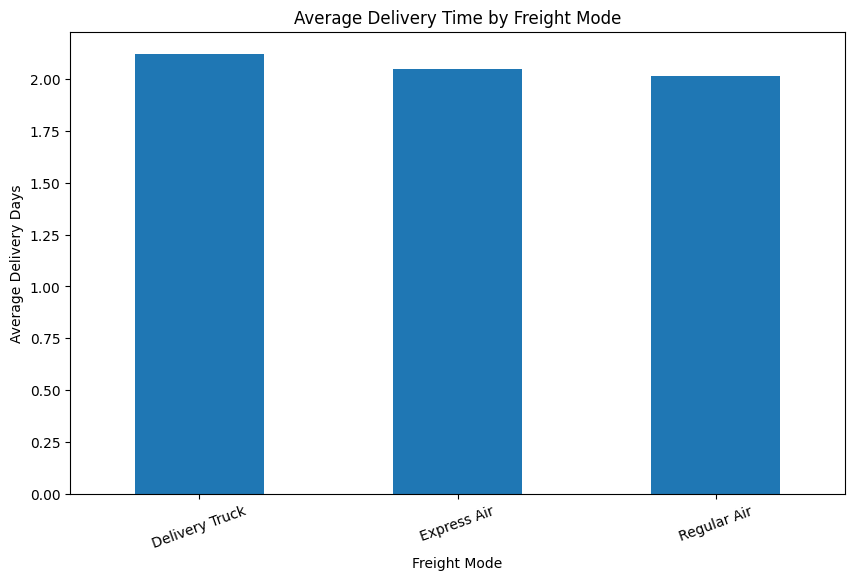

In [48]:
freight_performance.plot(
    x="Freight Mode",
    y="Average_Delivery_Days",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Average Delivery Time by Freight Mode")
plt.xlabel("Freight Mode")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=20)
plt.show()

### Interpretation

The three freight modes have similar average delivery times, ranging from 2.02 to 2.12 days. Regular Air handled the highest number of orders (1,892) and generated the highest total profit of 171,720.95. Delivery Truck had the highest average freight expense (42.79) and slightly longer delivery time. Overall, Regular Air shows strong financial performance with relatively low average freight expense and delivery time.

## 4.7 Business Question 7: What characteristics are associated with loss-making transactions?

### Why is this important?

The dataset contains both profitable and loss-making transactions. Identifying the characteristics of loss-making transactions can help the company understand where financial losses are concentrated.

Rather than examining the number of losses alone, this analysis compares loss-making and profit-making transactions across discounts, products, customer segments, regions and freight arrangements.

In [50]:
profitability_summary = (
    df.groupby("Profitability")
      .agg(
          Number_of_Orders=("Sales", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Discount=("Discount offered", "mean"),
          Average_Freight=("Freight Expenses", "mean"),
          Average_Quantity=("QtyOrdered", "mean"),
          Average_Delivery_Days=("Delivery Days", "mean")
      )
      .reset_index()
)

profitability_summary.round(2)

,Profitability,Number_of_Orders,Total_Sales,Total_Profit,Average_Discount,Average_Freight,Average_Quantity,Average_Delivery_Days
0,Loss-making,1248,815669.94,-358503.35,0.05,13.55,12.64,1.98
1,Profit-making,1286,1699638.56,643771.44,0.05,10.93,15.79,2.09


### Product analysis

In [51]:
loss_by_product = (
    df[df["Profitability"] == "Loss-making"]
    .groupby("Product Sub-Category")
    .agg(
        Loss_Making_Orders=("Profit", "count"),
        Total_Loss=("Profit", "sum"),
        Average_Loss=("Profit", "mean")
    )
    .sort_values("Total_Loss")
)

loss_by_product.head(10)

,Loss_Making_Orders,Total_Loss,Average_Loss
Product Sub-Category,,,
Sliced Pineapple,59,-81686.744912,-1384.521100
Jams,65,-36299.284845,-558.450536
Smoked Salmon,213,-31961.679520,-150.054833
Bacon,148,-31486.715708,-212.748079
Fresh Water Eel,94,-28371.627352,-301.825823
Marmalade,99,-24567.894063,-248.160546
Quail Eggs,108,-21404.780804,-198.192415
Sundried Tomatoes,53,-19124.510560,-360.839822
Assorted Fruits,99,-17749.499360,-179.287872


### Segment analysis

In [52]:
loss_by_segment = (
    df[df["Profitability"] == "Loss-making"]
    .groupby("Segment")
    .agg(
        Loss_Making_Orders=("Profit", "count"),
        Total_Loss=("Profit", "sum"),
        Average_Loss=("Profit", "mean")
    )
    .sort_values("Total_Loss")
)

loss_by_segment

,Loss_Making_Orders,Total_Loss,Average_Loss
Segment,,,
Hotels / Hospitals,439,-128344.997807,-292.357626
Personel Usage,292,-97407.994147,-333.589021
Restaurant Chain,307,-88563.099304,-288.479151
Stand Alone Restaurants,210,-44187.263182,-210.415539


### Discount comparison

In [53]:
profitability_discount = (
    df.groupby("Profitability")
      .agg(
          Average_Discount=("Discount offered", "mean"),
          Average_Profit=("Profit", "mean"),
          Average_Sales=("Sales", "mean")
      )
      .reset_index()
)

profitability_discount.round(2)

,Profitability,Average_Discount,Average_Profit,Average_Sales
0,Loss-making,0.05,-287.26,653.58
1,Profit-making,0.05,500.60,1321.65


### Interpretation

The analysis shows 1,248 loss-making orders compared with 1,286 profit-making orders. Hotels/Hospitals recorded the highest number of loss-making orders (439) and the largest total loss of 128,344.99. Personel Usage had the highest average loss per order at 333.59. At product level, Smoked Salmon had the most loss-making orders (213). Average discounts were the same for both groups, suggesting discount level alone does not explain the losses.

## 4.8 Business Question 8: How does order priority relate to delivery time, sales and profitability?

### Why is this important?

Order priority represents an operational decision concerning how orders are handled. Examining whether different priority levels are associated with differences in delivery duration, sales, freight expenses and profitability can provide useful information about the company's operational processes.

The analysis compares these measures across the available order-priority categories.

In [54]:
priority_performance = (
    df.groupby("Order Priority")
      .agg(
          Average_Delivery_Days=("Delivery Days", "mean"),
          Average_Freight_Expense=("Freight Expenses", "mean"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean"),
          Number_of_Orders=("Sales", "count")
      )
      .reset_index()
)

priority_performance.round(2)

,Order Priority,Average_Delivery_Days,Average_Freight_Expense,Total_Sales,Total_Profit,Average_Profit,Number_of_Orders
0,Critical,1.43,17.87,270500.21,23691.73,117.87,201
1,High,1.90,8.44,887295.31,138410.80,85.23,1624
2,Low,4.09,19.22,507205.62,64778.82,250.11,259
3,Medium,1.46,20.62,336408.84,42875.14,202.24,212
4,Not Specified,1.76,18.19,513898.52,15511.60,65.17,238


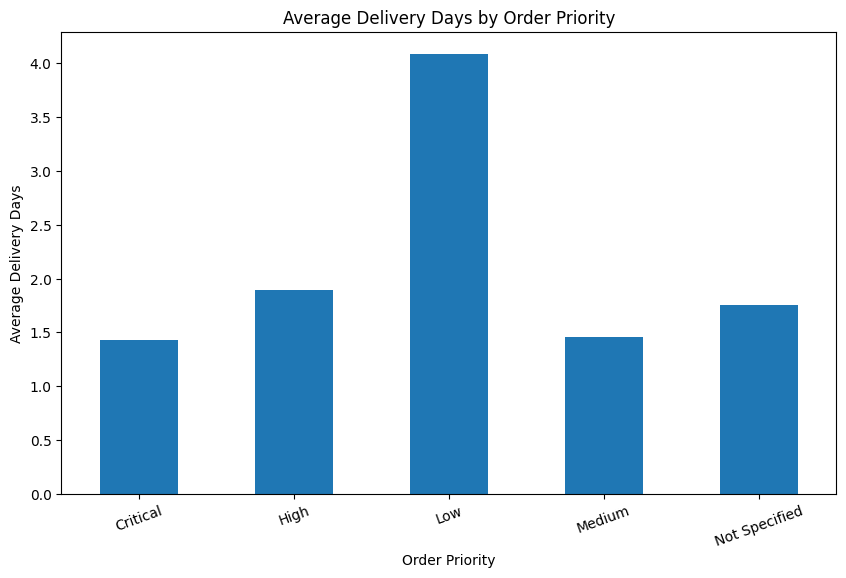

In [56]:
priority_performance.plot(
    x="Order Priority",
    y="Average_Delivery_Days",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Average Delivery Days by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=20)
plt.show()

### Interpretation

Order priority shows clear differences in delivery time. Low-priority orders had the longest average delivery time at 4.09 days, while Critical orders had the shortest at 1.43 days. High-priority orders generated the highest total sales (887,295.31) and profit (138,410.80). Low-priority orders had the highest average profit per order (250.11). Overall, priority levels are associated with differences in delivery time and financial performance.

## 5. Final Discussion

### 5.1 Key Findings
The analysis identified differences in sales, profit and operational performance across years, products, regions, customer segments, freight modes and order priorities. Sales increased over time, while profit declined in 2013. Regional and segment performance also varied considerably.

### 5.2 Business Implications
The findings suggest that high sales do not always result in high profitability. Differences between regions, products and customer segments can help identify areas requiring closer business attention.

### 5.3 Recommendations
The business should monitor loss-making products and segments, review factors affecting profit margins, and use regional and operational performance data to support future planning.

### 5.4 Strengths
The analysis used multiple business questions and different Pandas and visualisation techniques to examine sales, profitability and operational patterns from several perspectives.

### 5.5 Limitations
The dataset is observational, so the analysis identifies patterns and associations rather than causation. Discount analysis was also limited because all orders were within the 0–5 discount range.